In [2]:
import pandas as pd

In [4]:
import pandas as pd
df=pd.read_csv("data/netflix_titles.csv")
df.head()


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In this section, we analyze how Netflix expanded its content catalog overtime, focusing on movies and TV shows 

In [ ]:
df.info()


<bound method DataFrame.info of      show_id     type                  title         director  \
0         s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1         s2  TV Show          Blood & Water              NaN   
2         s3  TV Show              Ganglands  Julien Leclercq   
3         s4  TV Show  Jailbirds New Orleans              NaN   
4         s5  TV Show           Kota Factory              NaN   
...      ...      ...                    ...              ...   
8802   s8803    Movie                 Zodiac    David Fincher   
8803   s8804  TV Show            Zombie Dumb              NaN   
8804   s8805    Movie             Zombieland  Ruben Fleischer   
8805   s8806    Movie                   Zoom     Peter Hewitt   
8806   s8807    Movie                 Zubaan      Mozez Singh   

                                                   cast        country  \
0                                                   NaN  United States   
1     Ama Qamata, Khosi Ngema, Gail Mab

In [11]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [12]:
df['type'].value_counts()

type
Movie      6131
TV Show    2676
Name: count, dtype: int64

In [14]:
df['release_year'].value_counts().head(10)

release_year
2018    1147
2017    1032
2019    1030
2020     953
2016     902
2021     592
2015     560
2014     352
2013     288
2012     237
Name: count, dtype: int64

In [15]:
df.groupby('type')['release_year'].value_counts()

type     release_year
Movie    2017            767
         2018            767
         2016            658
         2019            633
         2020            517
                        ... 
TV Show  1963              1
         1974              1
         1945              1
         1925              1
         1972              1
Name: count, Length: 119, dtype: int64

In [49]:
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce')
df['date_year']=df['date_added'].dt.year
df.groupby('type')['date_year'].value_counts().groupby(level=0).head(10)

type     date_year
Movie    2019.0       1424
         2020.0       1284
         2018.0       1237
         2021.0        993
         2017.0        839
         2016.0        253
         2015.0         56
         2014.0         19
         2011.0         13
         2013.0          6
TV Show  2020.0        594
         2019.0        575
         2021.0        505
         2018.0        388
         2017.0        325
         2016.0        165
         2015.0         17
         2014.0          4
         2013.0          4
         2008.0          1
Name: count, dtype: int64

In [27]:
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


<function matplotlib.pyplot.show(close=None, block=None)>

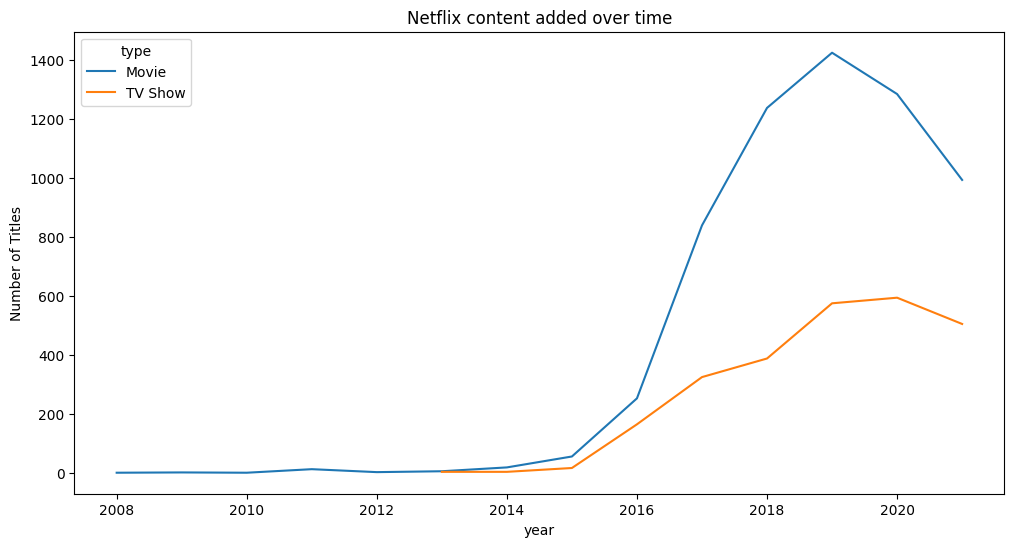

In [30]:
trend=df.groupby(['date_year','type']).size().unstack()
trend.plot(figsize=(12,6))
plt.title('Netflix content added over time')
plt.xlabel('year')
plt.ylabel('Number of Titles')
plt.show

From 2016, movie and tv show experenced rapid expand. Movie still holds the dominate position. TV show starts growing fast after 2016 and reach the peak.
### Key Findings

- Netflix experienced aggressive catalog expansion between 2016 and 2020.
- Movies continue to dominate the platform overall, suggesting that films remain the foundation of Netflix’s content library.
- TV Shows demonstrated particularly strong growth after 2018, potentially reflecting Netflix’s increasing focus on long-term user engagement and binge-watching behavior.

## Business Question 
- How has Netflix evolve into a global platform?

## Methodology

- To investigate Netflix’s global expansion strategy, the analysis focuses on country-level content distribution and temporal growth trends.

Missing values in the `country` column were excluded only for country-specific analyses. Content rankings were first examined to identify the major contributing countries and regions, followed by trend analysis over time for the top-performing countries.

In [50]:
df_country=df.dropna(subset=['country'])
df_country['country'].isnull().sum()
df_country['country'].value_counts().head(20)

country
United States                    2818
India                             972
United Kingdom                    419
Japan                             245
South Korea                       199
Canada                            181
Spain                             145
France                            124
Mexico                            110
Egypt                             106
Turkey                            105
Nigeria                            95
Australia                          87
Taiwan                             81
Indonesia                          79
Brazil                             77
United Kingdom, United States      75
Philippines                        75
United States, Canada              73
Germany                            67
Name: count, dtype: int64

In [38]:
top_countries=df_country['country'].value_counts().head(20)

## Visualization

Text(0, 0.5, 'Country')

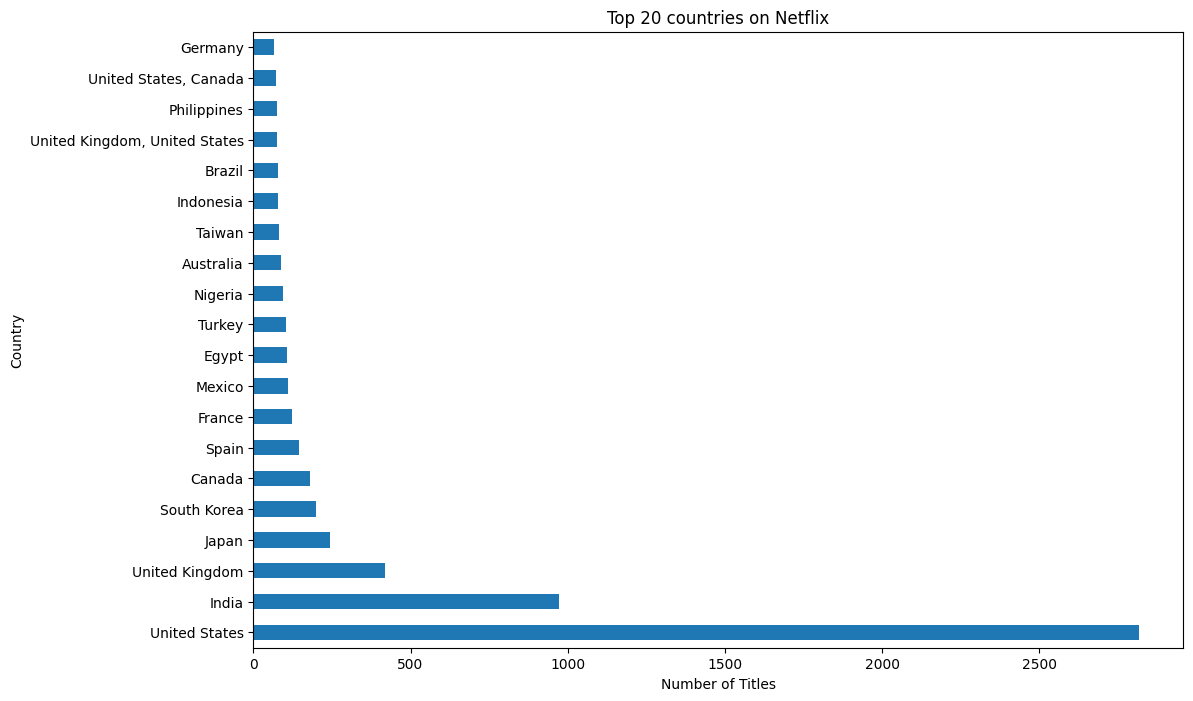

In [39]:
top_countries.plot(kind='barh',figsize=(12,8))
plt.title('Top 20 countries on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Country')


- ## Key Findings

- The United States contributes the largest share of Netflix titles by a substantial margin, with the number of U.S. titles exceeding more than twice that of India, the second-largest contributor.
- The United Kingdom ranks third, although its content volume is considerably lower than that of India.
- Countries ranked between 10th and 20th show relatively modest differences in title counts, suggesting a more balanced distribution among emerging international markets.
- Overall, the findings indicate that while Netflix has developed an increasingly international catalog, the platform still remains strongly dominated by U.S. productions.
- The growing presence of countries such as South Korea, Japan, Spain, and Turkey may reflect Netflix’s continued efforts to diversify its global content strategy and expand regional audience engagement.

### Netflix Global Content Strategy Analysis


## Asian Market Expansion Analysis

## Business Question

Has Netflix increasingly expanded its investment in Asian content markets over time?

## Hypothesis

Netflix has significantly increased Asian content offerings, particularly from countries such as South Korea, India, Japan, and Taiwan, as part of its global content diversification strategy.

In [51]:
asian_countries=['India','South Korea','Japan','Taiwan']
df_asia=df_country[df_country['country'].isin(asian_countries)]



In [52]:
df_asia.groupby(['date_year','country']).size().unstack()

country,India,Japan,South Korea,Taiwan
date_year,,,,
2015.0,NaN,1.0,NaN,NaN
2016.0,10.0,16.0,9.0,24.0
2017.0,141.0,27.0,36.0,11.0
2018.0,333.0,35.0,25.0,8.0
2019.0,203.0,57.0,53.0,20.0
2020.0,189.0,61.0,46.0,10.0
2021.0,95.0,44.0,26.0,8.0


In [54]:
asia_trend=df_asia.groupby(['date_year','country']).size().unstack()

## Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

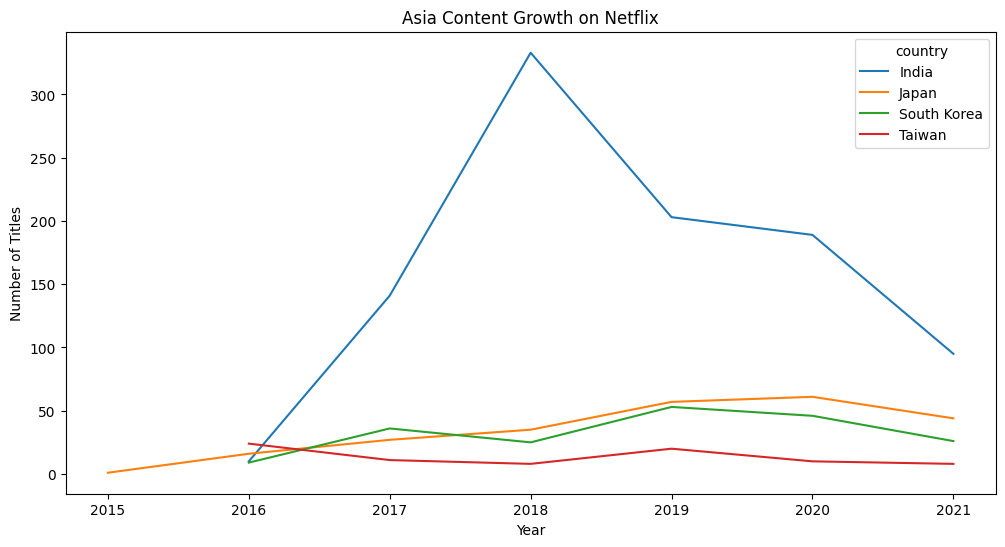

In [55]:
asia_trend.plot(figsize=(12,6))
plt.title('Asia Content Growth on Netflix')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show

### Key Findings

- Indian content experienced substantial growth after 2016 and reached a peak around 2018, suggesting Netflix’s increasing investment in the Indian entertainment market.
- Japanese and South Korean titles demonstrated relatively stable and consistent growth over time. In particular, the continued expansion of Korean content may reflect Netflix’s strategic focus on globally popular K-content and regional audience engagement.
- Taiwanese content remained comparatively limited in scale throughout the observed period, with annual additions remaining relatively stable at lower levels.
- Overall, the findings suggest that Netflix’s Asian content strategy has become increasingly diversified, with India, Japan, and South Korea emerging as key regional contributors to the platform’s international expansion.

## Business Question 
- How has international content collaboration evolved on Netflix over time?
## Hypothesis
- The growth of multinational co-productions may reflect Netflix’s increasing globalization and cross-regional content strategy.

In [62]:
df_country['is_coproduction']=df_country['country'].str.contains(',')
coproduction_trend=df_country.groupby(['date_year','is_coproduction']).size().unstack()
coproduction_trend

is_coproduction,False,True
date_year,,
2008.0,2.0,NaN
2009.0,2.0,NaN
2010.0,1.0,NaN
2011.0,11.0,2.0
2012.0,2.0,1.0
2013.0,8.0,2.0
2014.0,16.0,7.0
2015.0,58.0,12.0
2016.0,329.0,70.0


## Visualization

<function matplotlib.pyplot.show(close=None, block=None)>

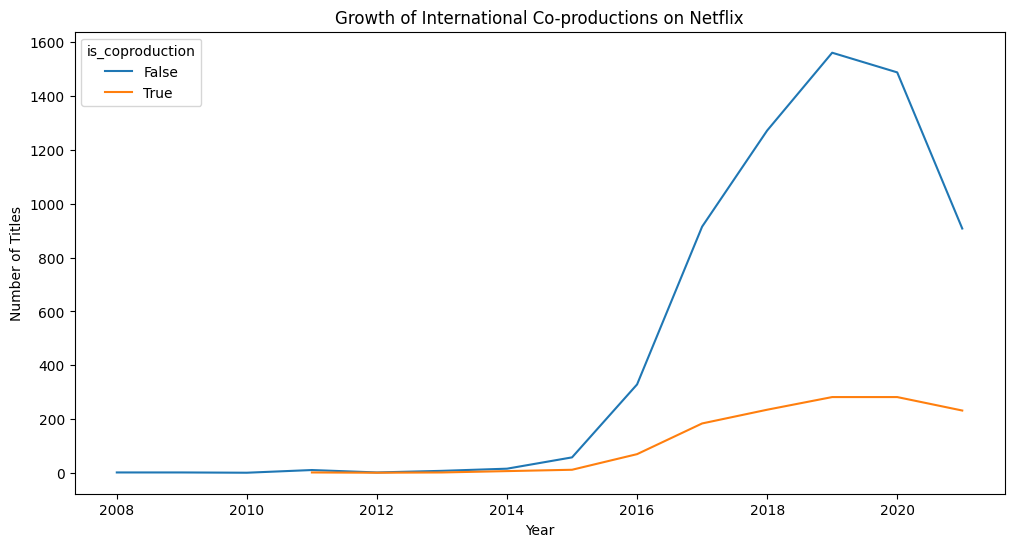

In [63]:
coproduction_trend.plot(figsize=(12,6))
plt.title('Growth of International Co-productions on Netflix')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.show

### Visualization Consideration

Although the comparison between co-productions and non-co-productions provides a general overview of Netflix’s catalog composition, this visualization may not effectively capture the globalization trend of co-productions themselves.

Because independently produced titles substantially outnumber multinational co-productions, the scale difference compresses the co-production trend visually and limits interpretability. Therefore, the globalization significance of co-productions should be examined independently rather than primarily through direct comparison with non-co-produced titles.

To better evaluate Netflix’s international collaboration strategy, a separate trend analysis focusing specifically on co-production growth and proportional change over time may provide more meaningful insights.

## proportion trend over time 

# title number each year

In [64]:
total_titles=df_country.groupby('date_year').size()
total_titles

date_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      70
2016.0     399
2017.0    1099
2018.0    1507
2019.0    1843
2020.0    1770
2021.0    1140
dtype: int64

In [65]:
coproduction_titles=df_country[df_country['is_coproduction']].groupby('date_year').size()
coproduction_titles

date_year
2011.0      2
2012.0      1
2013.0      2
2014.0      7
2015.0     12
2016.0     70
2017.0    184
2018.0    235
2019.0    282
2020.0    282
2021.0    232
dtype: int64

In [68]:
coproduction_share=coproduction_titles/total_titles
coproduction_share

date_year
2008.0         NaN
2009.0         NaN
2010.0         NaN
2011.0    0.153846
2012.0    0.333333
2013.0    0.200000
2014.0    0.304348
2015.0    0.171429
2016.0    0.175439
2017.0    0.167425
2018.0    0.155939
2019.0    0.153011
2020.0    0.159322
2021.0    0.203509
dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

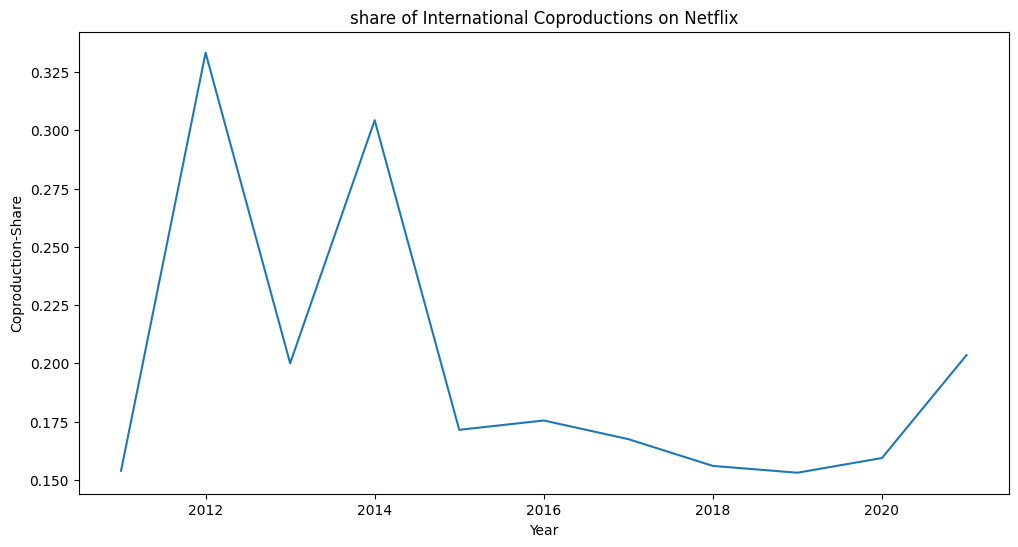

In [70]:
coproduction_share.plot(figsize=(12,6))
plt.title('share of International Coproductions on Netflix')
plt.xlabel('Year')
plt.ylabel('Coproduction-Share')
plt.show

## Key Findings

Although international co-productions increased in absolute numbers after 2015, the proportional share of co-produced titles did not demonstrate a clear and sustained upward trend over time.

The co-production share fluctuated across years, with local peaks observed around 2012 and 2014, followed by a gradual decline after 2016 before recovering slightly in 2021. These results suggest that, within the current dataset, multinational co-productions alone may not provide sufficient evidence to conclusively support a strong globalization trend in Netflix’s content strategy.

### Genre and country analysis
## Business question 
How do genre differ across countries, and what content categories may deserve stronger future investment in different markets?
## Analytical goal 
This section exams the relationship between country and genre to identify regional content patterns. The goal is to move beyond country level counts and explore what kinds of content different markets contribute to Netflix's catalog.

In [7]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

### Genre Distribution Across Major Netflix Markets

In this section, I analyze the genre composition of Netflix content across several major countries, including the United States, India, Japan, South Korea, Canada, and the United Kingdom.

The goal is to identify differences in content specialization, genre concentration, and regional storytelling preferences.

In [10]:
import pandas as pd
df=pd.read_csv ("data/netflix_titles.csv")
df['date_added']=pd.to_datetime(df['date_added'],errors='coerce') 
df['date_year']=df['date_added'].dt.year
df.head(50)


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,date_year
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,2021.0
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,2021-09-24,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,2021.0
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",2021-09-24,1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",2021.0
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,2021-09-24,2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...,2021.0
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021-09-24,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,2021.0


In [24]:
genre_country_df=df[['country','listed_in','type','duration','rating','date_year']]
genre_country_df.head(50)

,country,listed_in,type,duration,rating,date_year
0,United States,Documentaries,Movie,90 min,PG-13,2021.0
1,South Africa,"International TV Shows, TV Dramas, TV Mysteries",TV Show,2 Seasons,TV-MA,2021.0
2,NaN,"Crime TV Shows, International TV Shows, TV Act...",TV Show,1 Season,TV-MA,2021.0
3,NaN,"Docuseries, Reality TV",TV Show,1 Season,TV-MA,2021.0
4,India,"International TV Shows, Romantic TV Shows, TV ...",TV Show,2 Seasons,TV-MA,2021.0
5,NaN,"TV Dramas, TV Horror, TV Mysteries",TV Show,1 Season,TV-MA,2021.0
6,NaN,Children & Family Movies,Movie,91 min,PG,2021.0
7,"United States, Ghana, Burkina Faso, United Kin...","Dramas, Independent Movies, International Movies",Movie,125 min,TV-MA,2021.0
8,United Kingdom,"British TV Shows, Reality TV",TV Show,9 Seasons,TV-14,2021.0
9,United States,"Comedies, Dramas",Movie,104 min,PG-13,2021.0


In [25]:
df['date_year'].value_counts().sort_index()

date_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

In [49]:
df['country'].isna().sum()

np.int64(831)

In [ ]:

df['listed_in'].head(50)

0                                         Documentaries
1       International TV Shows, TV Dramas, TV Mysteries
2     Crime TV Shows, International TV Shows, TV Act...
3                                Docuseries, Reality TV
4     International TV Shows, Romantic TV Shows, TV ...
5                    TV Dramas, TV Horror, TV Mysteries
6                              Children & Family Movies
7      Dramas, Independent Movies, International Movies
8                          British TV Shows, Reality TV
9                                      Comedies, Dramas
10    Crime TV Shows, Docuseries, International TV S...
11    Crime TV Shows, International TV Shows, TV Act...
12                         Dramas, International Movies
13                   Children & Family Movies, Comedies
14         British TV Shows, Crime TV Shows, Docuseries
15                               TV Comedies, TV Dramas
16                  Documentaries, International Movies
17    Crime TV Shows, Spanish-Language TV Shows,

In [28]:
genre_country_df.head(10)

,country,listed_in,type,duration,rating,date_year
0,United States,[Documentaries],Movie,90 min,PG-13,2021.0
1,South Africa,"[International TV Shows, TV Dramas, TV Myste...",TV Show,2 Seasons,TV-MA,2021.0
2,NaN,"[Crime TV Shows, International TV Shows, TV ...",TV Show,1 Season,TV-MA,2021.0
3,NaN,"[Docuseries, Reality TV]",TV Show,1 Season,TV-MA,2021.0
4,India,"[International TV Shows, Romantic TV Shows, ...",TV Show,2 Seasons,TV-MA,2021.0
5,NaN,"[TV Dramas, TV Horror, TV Mysteries]",TV Show,1 Season,TV-MA,2021.0
6,NaN,[Children & Family Movies],Movie,91 min,PG,2021.0
7,"United States, Ghana, Burkina Faso, United Kin...","[Dramas, Independent Movies, International M...",Movie,125 min,TV-MA,2021.0
8,United Kingdom,"[British TV Shows, Reality TV]",TV Show,9 Seasons,TV-14,2021.0
9,United States,"[Comedies, Dramas]",Movie,104 min,PG-13,2021.0


In [31]:
genre_country_df=genre_country_df.explode('listed_in')
genre_country_df.head(50)

,country,listed_in,type,duration,rating,date_year
0,United States,Documentaries,Movie,90 min,PG-13,2021.0
1,South Africa,International TV Shows,TV Show,2 Seasons,TV-MA,2021.0
1,South Africa,TV Dramas,TV Show,2 Seasons,TV-MA,2021.0
1,South Africa,TV Mysteries,TV Show,2 Seasons,TV-MA,2021.0
2,NaN,Crime TV Shows,TV Show,1 Season,TV-MA,2021.0
2,NaN,International TV Shows,TV Show,1 Season,TV-MA,2021.0
2,NaN,TV Action & Adventure,TV Show,1 Season,TV-MA,2021.0
3,NaN,Docuseries,TV Show,1 Season,TV-MA,2021.0
3,NaN,Reality TV,TV Show,1 Season,TV-MA,2021.0
4,India,International TV Shows,TV Show,2 Seasons,TV-MA,2021.0


In [33]:
genre_country_df['listed_in'].value_counts().head(20)

listed_in
 International Movies       2624
Dramas                      1600
Comedies                    1210
Action & Adventure           859
Documentaries                829
 Dramas                      827
International TV Shows       774
 Independent Movies          736
 TV Dramas                   696
 Romantic Movies             613
Children & Family Movies     605
 International TV Shows      577
 Thrillers                   512
 Comedies                    464
 TV Comedies                 461
Crime TV Shows               399
Kids' TV                     388
 Music & Musicals            357
 Romantic TV Shows           338
Stand-Up Comedy              334
Name: count, dtype: int64

In [37]:
genre_by_country=genre_country_df.groupby(['country','listed_in']).size()
genre_by_country.head(20)

country            listed_in                 
, France, Algeria   Independent Movies            1
                    International Movies          1
                   Dramas                         1
, South Korea       TV Dramas                     1
                   International TV Shows         1
Argentina           Comedies                      1
                    Crime TV Shows                1
                    Cult Movies                   2
                    Docuseries                    1
                    Horror Movies                 1
                    Independent Movies            2
                    International Movies         28
                    International TV Shows        8
                    LGBTQ Movies                  1
                    Music & Musicals              3
                    Reality TV                    1
                    Romantic Movies               2
                    Romantic TV Shows             2
                  

In [75]:
genre_country_df=df[['country','listed_in','type','duration','rating','date_year']].copy()
genre_country_df=genre_country_df.dropna(subset=['country','listed_in'])
genre_country_df['country']=genre_country_df['country'].str.split(', ')
genre_country_df['listed_in']=genre_country_df['listed_in'].str.split(', ')
genre_country_df=genre_country_df.explode('country')
genre_country_df=genre_country_df.explode('listed_in')
genre_country_df.head(20)



,country,listed_in,type,duration,rating,date_year
0,United States,Documentaries,Movie,90 min,PG-13,2021.0
1,South Africa,International TV Shows,TV Show,2 Seasons,TV-MA,2021.0
1,South Africa,TV Dramas,TV Show,2 Seasons,TV-MA,2021.0
1,South Africa,TV Mysteries,TV Show,2 Seasons,TV-MA,2021.0
4,India,International TV Shows,TV Show,2 Seasons,TV-MA,2021.0
4,India,Romantic TV Shows,TV Show,2 Seasons,TV-MA,2021.0
4,India,TV Comedies,TV Show,2 Seasons,TV-MA,2021.0
7,United States,Dramas,Movie,125 min,TV-MA,2021.0
7,United States,Independent Movies,Movie,125 min,TV-MA,2021.0
7,United States,International Movies,Movie,125 min,TV-MA,2021.0


In [122]:
pd.set_option('display.max_rows',100)
genre_country_df.head(20)

,country,listed_in,type,duration,rating,date_year
0,United States,Documentaries,Movie,90 min,PG-13,2021.0
1,South Africa,International TV Shows,TV Show,2 Seasons,TV-MA,2021.0
1,South Africa,TV Dramas,TV Show,2 Seasons,TV-MA,2021.0
1,South Africa,TV Mysteries,TV Show,2 Seasons,TV-MA,2021.0
4,India,International TV Shows,TV Show,2 Seasons,TV-MA,2021.0
4,India,Romantic TV Shows,TV Show,2 Seasons,TV-MA,2021.0
4,India,TV Comedies,TV Show,2 Seasons,TV-MA,2021.0
7,United States,Dramas,Movie,125 min,TV-MA,2021.0
7,United States,Independent Movies,Movie,125 min,TV-MA,2021.0
7,United States,International Movies,Movie,125 min,TV-MA,2021.0


In [77]:
genre_by_country=genre_country_df.groupby(['country','listed_in']).size().sort_values(ascending=False)
genre_by_country.head(50)

country         listed_in               
India           International Movies        864
United States   Dramas                      835
                Comedies                    680
India           Dramas                      662
United States   Documentaries               511
                Action & Adventure          404
                Independent Movies          390
                Children & Family Movies    390
India           Comedies                    323
United States   Thrillers                   292
                TV Comedies                 258
                TV Dramas                   232
                Romantic Movies             225
United Kingdom  British TV Shows            225
United States   Stand-Up Comedy             216
                Kids' TV                    214
France          International Movies        207
United States   Horror Movies               201
United Kingdom  Dramas                      196
United States   Docuseries                  192

In [88]:
genre_by_country_df=genre_country_df.groupby(['country','listed_in']).size().reset_index(name='count')
genre_by_country_df.head(20)

,country,listed_in,count
0,,Dramas,1
1,,Independent Movies,1
2,,International Movies,1
3,,International TV Shows,1
4,,TV Dramas,1
5,Afghanistan,Documentaries,1
6,Afghanistan,International Movies,1
7,Albania,Dramas,1
8,Albania,International Movies,1
9,Algeria,Classic Movies,1


In [79]:
genre_by_country_df=genre_by_country_df.sort_values(by='count',ascending=False)
genre_by_country_df.head(50)

,country,listed_in,count
526,India,International Movies,864
1351,United States,Dramas,835
1346,United States,Comedies,680
522,India,Dramas,662
1349,United States,Documentaries,511
1339,United States,Action & Adventure,404
1354,United States,Independent Movies,390
1343,United States,Children & Family Movies,390
517,India,Comedies,323
1380,United States,Thrillers,292


##### United States Genre Distribution

The United States represents one of Netflix’s largest and most diversified content markets. This analysis examines the top genre categories within U.S.-related Netflix content.

In [136]:
us_genre=genre_by_country_df[genre_by_country_df['country']=='United States']
us_genre=us_genre.sort_values(by='count',ascending=False)
us_genre_top10=us_genre.head(10)
us_genre_top10



,country,listed_in,count
1351,United States,Dramas,835
1346,United States,Comedies,680
1349,United States,Documentaries,511
1339,United States,Action & Adventure,404
1354,United States,Independent Movies,390
1343,United States,Children & Family Movies,390
1380,United States,Thrillers,292
1372,United States,TV Comedies,258
1373,United States,TV Dramas,232
1363,United States,Romantic Movies,225


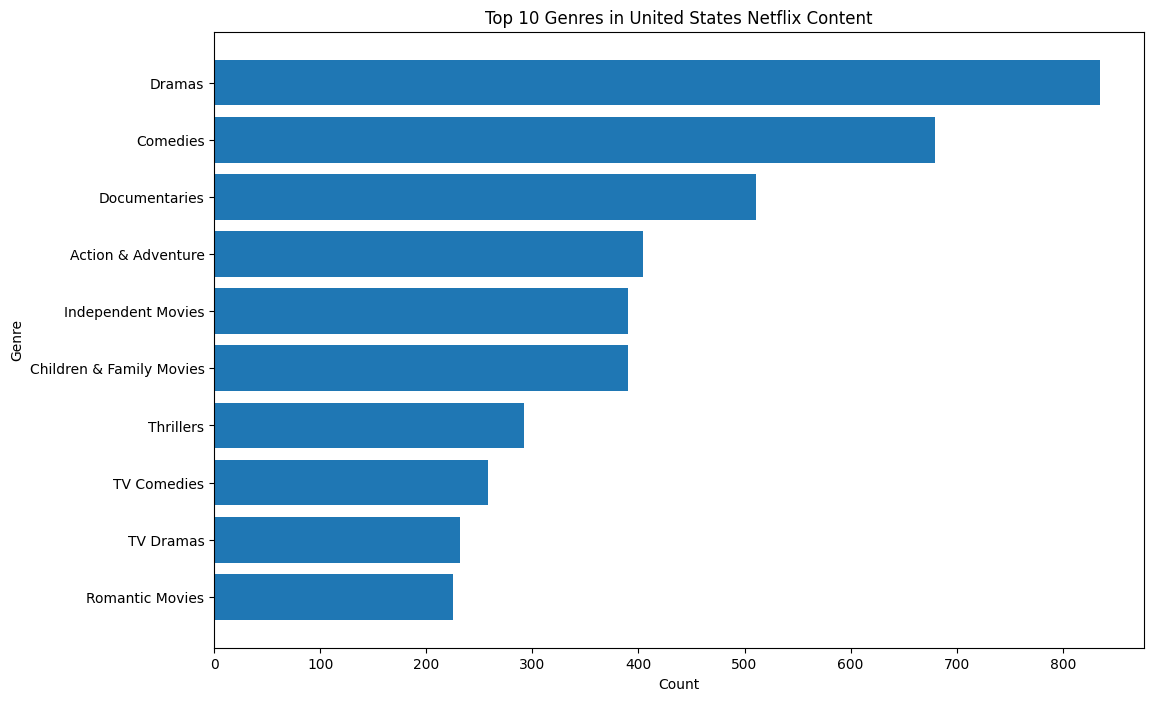

In [144]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,8))
plt.barh(us_genre_top10['listed_in'],us_genre_top10['count'])
plt.title('Top 10 Genres in United States Netflix Content')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.savefig('figures/us_genre_top10.png',bbox_inches='tight')
plt.show()
plt.close()

## Key Findings – United States

**Observations**

- Dramas and Comedies represent the largest categories within Netflix’s U.S. content portfolio.
- Documentaries also maintain a substantial presence, suggesting strong investment in nonfiction and educational storytelling.
- Several genres, including Action & Adventure, Independent Movies, and Children & Family Movies, maintain relatively comparable representation levels.

**Business Interpretation**

The U.S. catalog demonstrates a relatively balanced genre distribution across multiple entertainment categories. Rather than relying on a single dominant content type, Netflix appears to maintain a diversified portfolio strategy designed to serve broad audience segments, including family viewers, documentary audiences, and mainstream entertainment consumers.

#### The Indian Netflix catalog is strongly centered around movie-oriented storytelling, particularly dramas and international films. This section examines the dominant genre categories within Netflix content associated with India.

In [113]:
india_genre=genre_by_country_df[genre_by_country_df['country']=='India']
india_genre=india_genre.sort_values(by='count',ascending=False)
india_genre.head(10)


,country,listed_in,count
526,India,International Movies,864
522,India,Dramas,662
517,India,Comedies,323
525,India,Independent Movies,167
513,India,Action & Adventure,137
532,India,Romantic Movies,120
530,India,Music & Musicals,96
547,India,Thrillers,92
527,India,International TV Shows,66
524,India,Horror Movies,35


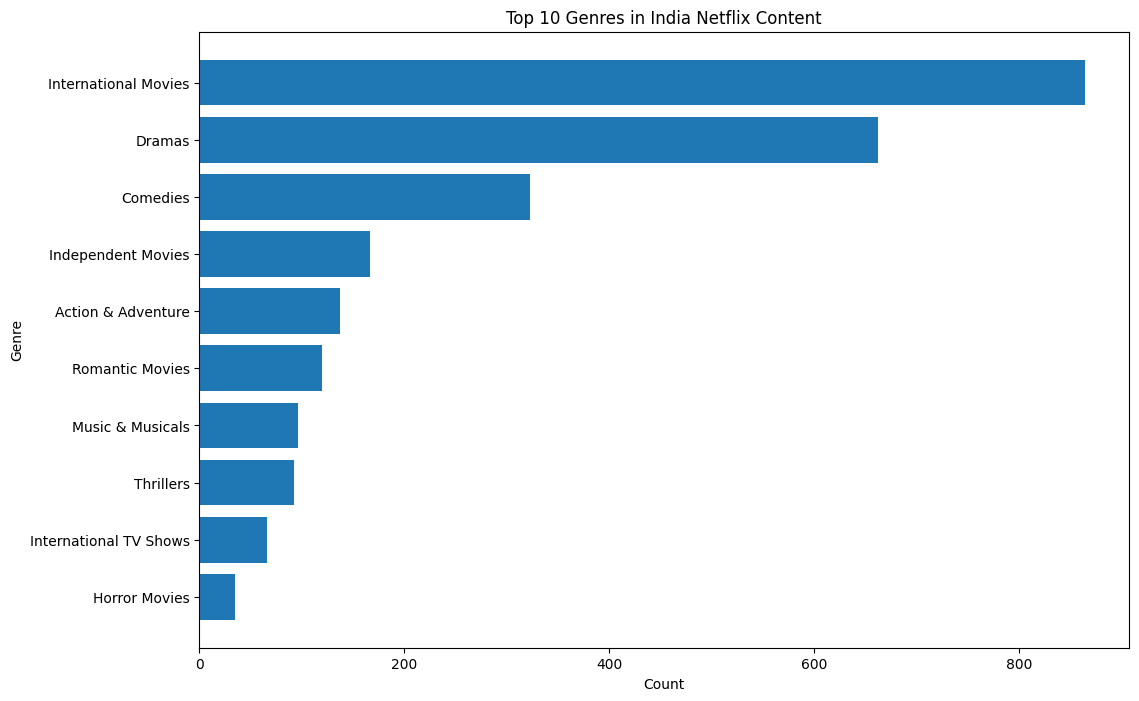

In [139]:
india_genre_top10=india_genre.head(10)
plt.figure(figsize=(12,8))
plt.barh(india_genre_top10['listed_in'],india_genre_top10['count'])
plt.title('Top 10 Genres in India Netflix Content')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.savefig('figures/india_genre_top10.png',bbox_inches='tight')
plt.show()
plt.close()

## Key Findings – India

**Observations**

- International Movies and Dramas dominate Netflix’s Indian content catalog by a substantial margin.
- Comedies remain important but appear significantly smaller than the two leading genres.
- Most remaining genres decline rapidly in volume after the top categories.

**Business Interpretation**

The Indian catalog appears highly concentrated in drama-oriented and movie-focused storytelling. Compared with the United States, Netflix’s India-related content strategy may prioritize a smaller set of high-demand genres rather than maintaining broad genre diversification.

#### The United Kingdom maintains a strong television-focused content profile, led by British TV productions and drama-related categories. This analysis explores the leading genres within Netflix’s U.K.-related catalog.

In [87]:
uk_genre=genre_by_country_df[genre_by_country_df['country']=='United Kingdom']
uk_genre=uk_genre.sort_values(by='count',ascending=False)
uk_genre.head(10)

,country,listed_in,count
1300,United Kingdom,British TV Shows,225
1309,United Kingdom,Dramas,196
1313,United Kingdom,International Movies,168
1314,United Kingdom,International TV Shows,128
1307,United Kingdom,Documentaries,127
1304,United Kingdom,Comedies,91
1308,United Kingdom,Docuseries,89
1299,United Kingdom,Action & Adventure,84
1312,United Kingdom,Independent Movies,74
1335,United Kingdom,Thrillers,61


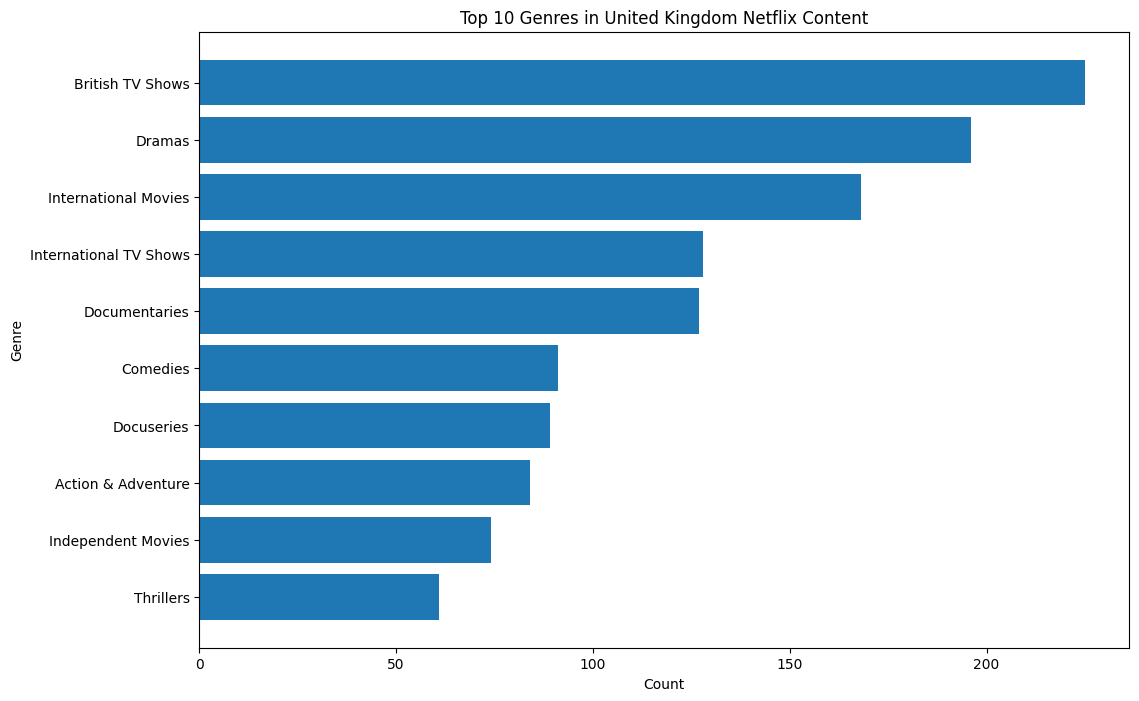

In [140]:
uk_genre_top10=uk_genre.head(10)
plt.figure(figsize=(12,8))
plt.barh(uk_genre_top10['listed_in'],uk_genre_top10['count'])
plt.title('Top 10 Genres in United Kingdom Netflix Content')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.savefig('figures/uk_genre_top10.png',bbox_inches='tight')
plt.show()
plt.close()


## Key Findings – United Kingdom

**Observations**

- British TV Shows represent the largest category within the U.K. catalog.
- Dramas and International Movies also maintain strong representation.
- Documentaries and International TV Shows occupy meaningful portions of the catalog as well.

**Business Interpretation**

The U.K. catalog shows a strong emphasis on television-oriented storytelling, particularly British-produced TV content. Compared with some other countries, the U.K. portfolio appears more balanced between domestic television identity and internationally distributed content.

#### Japan demonstrates a distinctive content profile characterized by strong representation of anime and serialized television content. This section analyzes the dominant genre categories within Netflix’s Japanese content catalog.

In [124]:
japan_genre=genre_by_country_df[genre_by_country_df['country']=='Japan']
japan_genre=japan_genre.sort_values(by='count',ascending=False)
japan_genre_top10=japan_genre.head(10)
japan_genre_top10
                                    

,country,listed_in,count
663,Japan,International TV Shows,151
650,Japan,Anime Series,143
662,Japan,International Movies,72
649,Japan,Anime Features,61
648,Japan,Action & Adventure,57
664,Japan,Kids' TV,29
659,Japan,Dramas,23
676,Japan,TV Dramas,21
670,Japan,Romantic TV Shows,21
652,Japan,Children & Family Movies,19


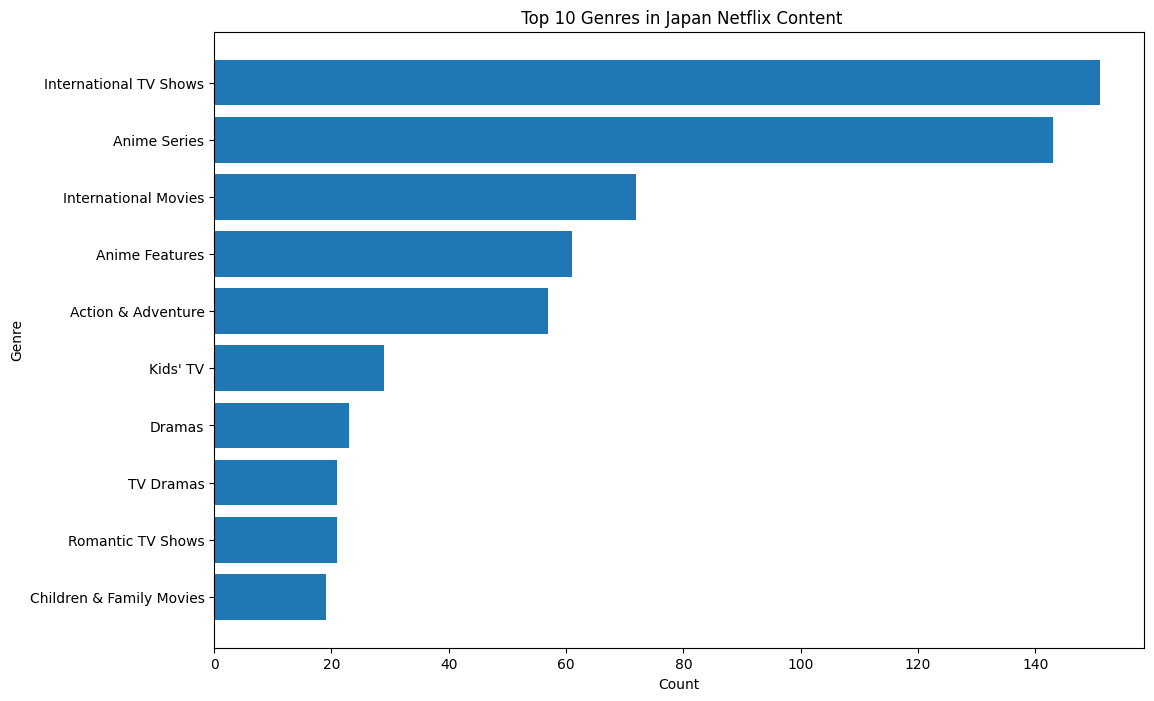

In [141]:
plt.figure(figsize=(12,8))
plt.barh(japan_genre_top10['listed_in'],japan_genre_top10['count'])
plt.title(' Top 10 Genres in Japan Netflix Content')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.savefig('figures/japan_gnre_top10',bbox_inches='tight')
plt.show()
plt.close()

## Key Findings – Japan

**Observations**

- International TV Shows and Anime Series are the two most represented categories in the Japanese catalog.
- Anime Features also maintain strong representation compared with other countries.
- Traditional drama categories occupy smaller portions of the catalog relative to animation-focused content.

**Business Interpretation**

Japan demonstrates a highly differentiated content profile centered around animation and serialized television content. Rather than competing through broad genre diversification, Japanese content appears to contribute unique niche categories that may attract highly engaged global audiences.

#### South Korea’s Netflix catalog is heavily oriented toward television storytelling, particularly Korean TV shows and romantic series. This analysis examines the leading genres within Netflix content associated with South Korea. 

In [131]:
south_korea_genre=genre_by_country_df[genre_by_country_df['country']=='South Korea']
south_korea_genre=south_korea_genre.sort_values(by='count',ascending=False)
south_korea_genre_top10=south_korea_genre.head(10)
south_korea_genre_top10

,country,listed_in,count
1109,South Korea,International TV Shows,152
1111,South Korea,Korean TV Shows,132
1117,South Korea,Romantic TV Shows,77
1108,South Korea,International Movies,44
1123,South Korea,TV Dramas,38
1105,South Korea,Dramas,26
1102,South Korea,Crime TV Shows,24
1122,South Korea,TV Comedies,19
1099,South Korea,Action & Adventure,17
1101,South Korea,Comedies,17


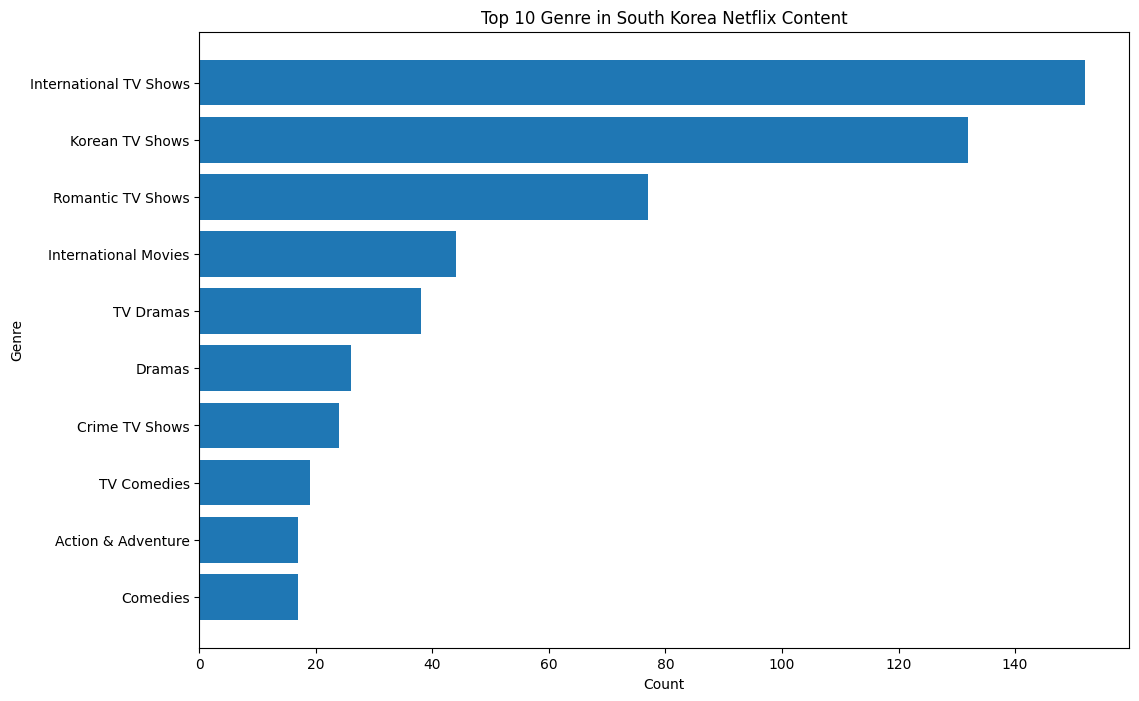

In [142]:
plt.figure(figsize=(12,8))
plt.barh(south_korea_genre_top10['listed_in'],south_korea_genre_top10['count'])
plt.title('Top 10 Genre in South Korea Netflix Content')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.savefig('figures/south_korea_genre_top10.png',bbox_inches='tight')
plt.show()
plt.close()

## Key Findings – South Korea

**Observations**

- International TV Shows and Korean TV Shows dominate Netflix’s South Korean content portfolio.
- Romantic TV Shows maintain significantly higher representation than in many other countries.
- Movie-oriented genres occupy a smaller share relative to television-focused categories.

**Business Interpretation**

The South Korean catalog demonstrates a strong specialization in serialized television storytelling. The prominence of Korean TV Shows and Romantic TV content suggests that long-form episodic narratives represent a major strength of South Korea’s global entertainment exports.

#### Canada’s Netflix catalog reflects a relatively balanced mix of entertainment, family-oriented, and movie-focused content categories. This section examines the dominant genres represented within Canadian Netflix content.

In [133]:
canada_genre=genre_by_country_df[genre_by_country_df['country']=='Canada']
canada_genre=canada_genre.sort_values('count',ascending=False)
canada_genre_top10=canada_genre.head(10)
canada_genre_top10

,country,listed_in,count
182,Canada,Comedies,94
187,Canada,Dramas,82
180,Canada,Children & Family Movies,80
193,Canada,Kids' TV,61
191,Canada,International Movies,60
213,Canada,Thrillers,49
190,Canada,Independent Movies,44
177,Canada,Action & Adventure,44
185,Canada,Documentaries,42
189,Canada,Horror Movies,36


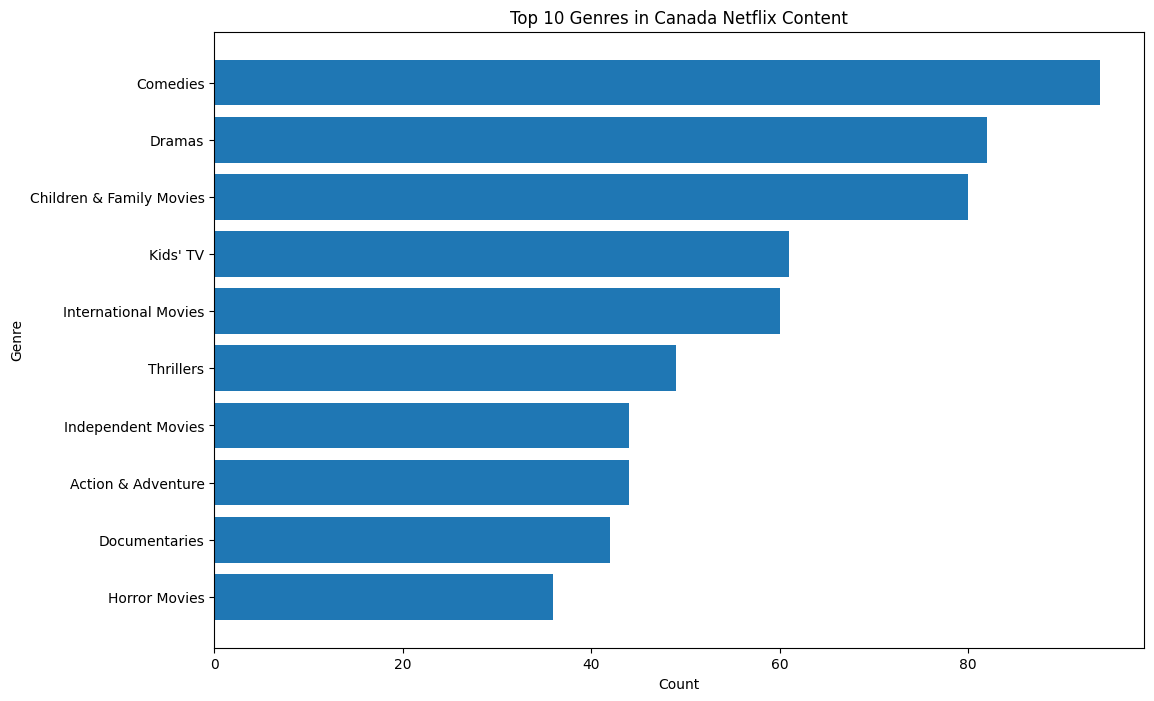

In [143]:
plt.figure(figsize=(12,8))
plt.barh(canada_genre_top10['listed_in'],canada_genre_top10['count'])
plt.title('Top 10 Genres in Canada Netflix Content')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.savefig('figures/canada_genre_top10.png',bbox_inches='tight')
plt.show()
plt.close()

## Key Findings – Canada

**Observations**

- Comedies and Dramas are the largest categories within the Canadian catalog.
- Children & Family Movies and Kids’ TV also maintain substantial representation.
- Genre distribution appears relatively balanced across entertainment, family, and movie-oriented content categories.

**Business Interpretation**

Compared with some more specialized content markets, Canada’s catalog reflects a broader and more balanced content composition. The strong presence of family-oriented genres may indicate a strategy focused on wide demographic accessibility and mainstream audience appeal.